# Starbucks User Segmentation

Aditya Raj
IIT BHU'26

### Table of Contents:

-  Business Understanding
-  Data Understanding
- Data Preparation

### 1. Business Understanding

Starbucks Corporation is an American coffee company. Today, it operates more than 30,000 retail stores in 80 markets around the world.[[1]](https://www.starbucks.com/about-us/company-information/starbucks-company-profile) The company hence is a big player in a vigorously competitive industry. One approach to retain customers is its [Starbucks Reward Program](https://www.starbucks.com/rewards). Members of the program receive promotional offers. The company then hopes to use the data collected on its customer behavior to create business value and make data-driven decisions on how it engages with its customers base.

### Project Overview

The motivation behind this project is to propose a solution that helps the company in forming a better understanding of its customers base. In this project, an unsupervised learning technique will be used to segment customers and measure how each segment behave during different periods of the test. In particular, [K-Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) clustering will be used. The provided dataset of courses will go through different phases at first before being ready for modeling. Starting with cleaning and ending with the final dataset grouped by customer profiles with their data aggreated.

Here's a high-level overview of the workflow followed in this project:
- Define the problem in-hands and measurement criterias.
- Explore, understand, and clean the provided datasets.
- Prepare final dataset grouped by customers.
- Transform final dataset appropriately before fitting model.
- Fit model on final dataset and predict cluster labels.
- Explore distributions among formed clusters.
- Discuss outcomes and make recommendations.

## 2. Data Understanding

This data set contains simulated data that mimics customer behavior on the Starbucks Rewards mobile app. Once every few days, Starbucks sends out an offer to users of the mobile app. An offer can be merely an advertisement for a drink (informational) or an actual offer such as a discount or BOGO (buy one get one free). This data set is a simplified version of the real Starbucks app because the underlying simulator only has one product whereas Starbucks actually sells dozens of products.

The data is contained in three files mentioned below in brief and will be discussed in details later.

* `data/portfolio.json` - containing meta data about the promotions offered by the company.
* `data/profile.json` - demographic data about members enrolled in the reward program.
* `data/transcript.json` - records for transactions, offers received, offers viewed, and offers completed

### Importing libraries

In [159]:
from IPython.display import display
import pandas as pd
import numpy as np
import json
import time

from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, LabelEncoder
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('ggplot')
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")  


In [160]:
# Read in the json files


portfolio = pd.read_json(r"C:\Users\Aditya\Data Science Jupyter\ml projects\User Segmentation\datasets\portfolio.json", orient='records', lines=True)
profile = pd.read_json(r"C:\Users\Aditya\Data Science Jupyter\ml projects\User Segmentation\datasets\profile.json", orient='records', lines=True)
transcript = pd.read_json(r"C:\Users\Aditya\Data Science Jupyter\ml projects\User Segmentation\datasets\transcript.json", orient='records', lines=True)

### 2.1. `portfolio` Dataset
This dataset contains meta data about promotions offered by the company. 

**Schema:**  
* `id` (str) - offer id
* `offer_type` (str) - type of offer; bogo, discount, or informational
* `difficulty` (int) - minimum required to be spent to complete an offer
* `reward` (int) - reward given for completing an offer
* `duration` (int) - time in days for an offer to be open
* `channels` (list) - communication channels used to market an offer.

In [161]:
portfolio.head()

,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [162]:
portfolio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reward      10 non-null     int64 
 1   channels    10 non-null     object
 2   difficulty  10 non-null     int64 
 3   duration    10 non-null     int64 
 4   offer_type  10 non-null     object
 5   id          10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [163]:
#checking null values
portfolio.isnull().sum()

reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64

### 2.2. `profile` Dataset

This dataset contains demographic data about members enrolled in the reward program with self-explanatory features.

**Schema:**
  
* `age` (int) - age of the customer
* `became_member_on` (int) - date when customer created an app account
* `gender` (str) - gender of the customer; M, F, or O.
* `id` (str) - customer id
* `income` (float) - income of customer

In [164]:
profile.head()

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [165]:
profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            14825 non-null  object 
 1   age               17000 non-null  int64  
 2   id                17000 non-null  object 
 3   became_member_on  17000 non-null  int64  
 4   income            14825 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 664.2+ KB


In [166]:
# Check null values
profile.isnull().sum()

gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [167]:
# Check
profile[profile.gender.isnull() == True].head(10)

,gender,age,id,became_member_on,income
0,None,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
2,None,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
4,None,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
6,None,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,None,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
9,None,118,8974fc5686fe429db53ddde067b88302,20161122,NaN
10,None,118,c4863c7985cf408faee930f111475da3,20170824,NaN
11,None,118,148adfcaa27d485b82f323aaaad036bd,20150919,NaN
17,None,118,744d603ef08c4f33af5a61c8c7628d1c,20170801,NaN
23,None,118,2b826eba31074a059d63b0ae8f50b7d5,20170907,NaN


In [168]:
# value_counts of income where gender is null
profile[profile.gender.isnull() == True].income.value_counts(dropna=False)

income
NaN    2175
Name: count, dtype: int64

In [169]:
# value_counts of `age` where `gender` is null
profile[profile.gender.isnull() == True].age.value_counts()

age
118    2175
Name: count, dtype: int64

This simply shows that for the the 2175 profiles where gender is null, income is also null, and age is set to 118. Indicating a problem with these records.

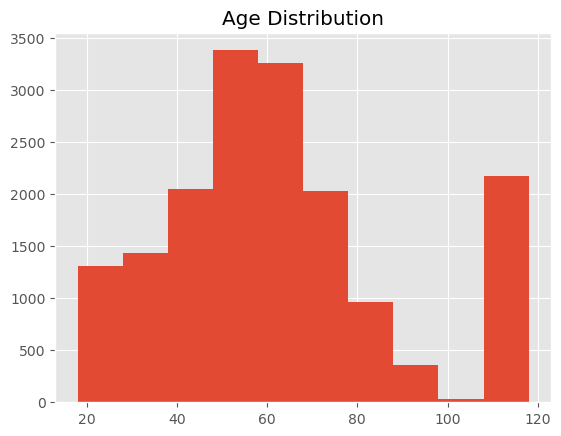

In [170]:
# Check age distribution

plt.hist(profile['age']);
plt.title('Age Distribution');

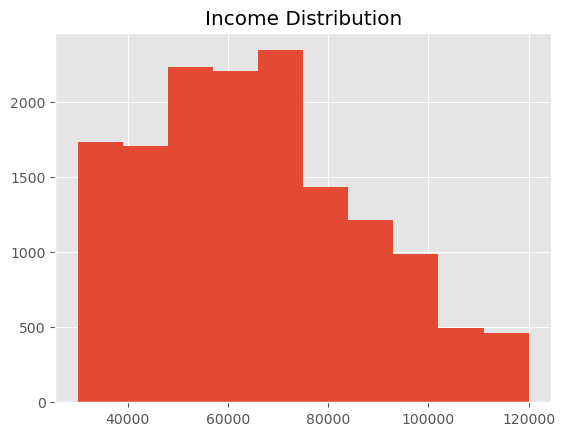

In [171]:
# Check income distribution

plt.hist(profile['income'].dropna());
plt.title('Income Distribution');

In [172]:
profile['gender'].value_counts()

gender
M    8484
F    6129
O     212
Name: count, dtype: int64

### 2.3. `transcript` Dataset

This dataset contains records of activities related to the test simulated. Each record is time-stamped since the start of the test. The test start at t=0 and ends at t=714 (≈ 30 days).

**Schema:**
* `event` (str) - record description; transaction, offer received, offer viewed, or offer completed.
* `person` (str) - customer id.
* `time` (int) - time in hours since start of test. The data begins at time t=0.
* `value` - (dict) - either an offer id or transaction amount depending on the record.

In [173]:
transcript.tail()

,person,event,value,time
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,{'amount': 1.5899999999999999},714
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,{'amount': 9.53},714
306531,a00058cf10334a308c68e7631c529907,transaction,{'amount': 3.61},714
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,{'amount': 3.5300000000000002},714
306533,c02b10e8752c4d8e9b73f918558531f7,transaction,{'amount': 4.05},714


In [174]:
transcript.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   person  306534 non-null  object
 1   event   306534 non-null  object
 2   value   306534 non-null  object
 3   time    306534 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 9.4+ MB


In [175]:
transcript['event'].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

In [176]:
# Check test period
print(transcript.time.max(), 'hours')
print(transcript.time.max() / 24, 'days')

714 hours
29.75 days


## 3. Data Preparation

In this section, different compantions of techniques will be performed to produce the final dataset ready for modeling next section. Starting with cleaning the provided datasets, and then merging and aggregating data to form the final dataset. The final dataset will be grouped by customers profiles.

### 3.1. Data Cleaning

#### 3.1.1. `portfolio` Dataset


In [177]:
# Rename specified columns
portfolio.rename(columns={
    'id': 'offer_id',
    'reward': 'offered_reward'}, inplace=True)

- One-hot encoding for columns `channels` and `offer_type` using `OneHotEncoder`.

In [178]:

#Encode channels
mlb = MultiLabelBinarizer(classes=['web','email','mobile','social'])
channels_df = pd.DataFrame(
    mlb.fit_transform(portfolio['channels']),
    columns=[f"channel_{c}" for c in mlb.classes_],
    index=portfolio.index
)

# Encode offer_type
ohe = OneHotEncoder(categories=[['discount','bogo','informational']], 
                    handle_unknown="ignore", sparse_output=False)

types_encoded = ohe.fit_transform(portfolio[['offer_type']])
types_df = pd.DataFrame(
    types_encoded.astype(int), 
    columns=[f"type_{c}" for c in ohe.categories_[0]], 
    index=portfolio.index
)

# Merging everything back 
portfolio = pd.concat(
    [portfolio.drop(columns=['channels','offer_type']), channels_df, types_df],
    axis=1
)


In [179]:
portfolio

,offered_reward,difficulty,duration,offer_id,channel_web,channel_email,channel_mobile,channel_social,type_discount,type_bogo,type_informational
0,10,10,7,ae264e3637204a6fb9bb56bc8210ddfd,0,1,1,1,0,1,0
1,10,10,5,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1,0,1,0
2,0,0,4,3f207df678b143eea3cee63160fa8bed,1,1,1,0,0,0,1
3,5,5,7,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,1,0,0,1,0
4,5,20,10,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,1,0,0,1,0,0
5,3,7,7,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1,1,0,0
6,2,10,10,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1,1,0,0
7,0,0,3,5a8bc65990b245e5a138643cd4eb9837,0,1,1,1,0,0,1
8,5,5,5,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1,0,1,0
9,2,10,7,2906b810c7d4411798c6938adc9daaa5,1,1,1,0,1,0,0


In [180]:
# Encoding offer_id
codes, uniques = pd.factorize(portfolio['offer_id'], sort=False)

# Replacing column with integers starting from 1
portfolio['offer_id'] = codes + 1

# Creating mapping dictionary (original_id → integer)
offer_id_dict = dict(zip(uniques, codes + 1))


In [181]:
offer_id_dict

{'ae264e3637204a6fb9bb56bc8210ddfd': 1,
 '4d5c57ea9a6940dd891ad53e9dbe8da0': 2,
 '3f207df678b143eea3cee63160fa8bed': 3,
 '9b98b8c7a33c4b65b9aebfe6a799e6d9': 4,
 '0b1e1539f2cc45b7b9fa7c272da2e1d7': 5,
 '2298d6c36e964ae4a3e7e9706d1fb8c2': 6,
 'fafdcd668e3743c1bb461111dcafc2a4': 7,
 '5a8bc65990b245e5a138643cd4eb9837': 8,
 'f19421c1d4aa40978ebb69ca19b0e20d': 9,
 '2906b810c7d4411798c6938adc9daaa5': 10}

In [182]:
portfolio.head()

,offered_reward,difficulty,duration,offer_id,channel_web,channel_email,channel_mobile,channel_social,type_discount,type_bogo,type_informational
0,10,10,7,1,0,1,1,1,0,1,0
1,10,10,5,2,1,1,1,1,0,1,0
2,0,0,4,3,1,1,1,0,0,0,1
3,5,5,7,4,1,1,1,0,0,1,0
4,5,20,10,5,1,1,0,0,1,0,0


In [183]:
portfolio.isnull().sum()

offered_reward        0
difficulty            0
duration              0
offer_id              0
channel_web           0
channel_email         0
channel_mobile        0
channel_social        0
type_discount         0
type_bogo             0
type_informational    0
dtype: int64

#### 3.1.2. `profile` Dataset

In [184]:
# Renaming id column to customer_id

profile.rename(columns={'id': 'customer_id'}, inplace=True)

In [185]:
# Converting became_member_on to standard datetime object
profile['became_member_on'] = pd.to_datetime(profile['became_member_on'], format='%Y%m%d')

# Adding calculated days_member column
profile['days_member'] = (pd.to_datetime('today') - profile['became_member_on']).dt.days

# Dropping became_member_on
profile.drop(columns='became_member_on', inplace=True)


In [186]:
# Retain customer_id of rows to be deleted to later remove corresponding rows in transcript
dropped_profiles = profile[
    (profile.gender.isnull() == True) | (profile.gender == 'O')].customer_id.values

# Drop rows using the list produced in dropped_profiles above
profile.drop(profile[profile.customer_id.isin(dropped_profiles) == True].index, inplace=True)

# Reset index
profile.reset_index(drop=True, inplace=True)

In [187]:
# Remaping gender column using binary values
profile.gender = profile.gender.map({'F':0, 'M':1})

In [188]:
# Encode customer_id 
codes, uniques = pd.factorize(profile['customer_id'], sort=False)

# Replace column with integers starting from 1
profile['customer_id'] = codes + 1

# Create mapping dictionary (original_id → integer)
customer_id_dict = dict(zip(uniques, codes + 1))


In [189]:
dict(list(customer_id_dict.items())[0:5])

{'0610b486422d4921ae7d2bf64640c50b': 1,
 '78afa995795e4d85b5d9ceeca43f5fef': 2,
 'e2127556f4f64592b11af22de27a7932': 3,
 '389bc3fa690240e798340f5a15918d5c': 4,
 '2eeac8d8feae4a8cad5a6af0499a211d': 5}

In [190]:
profile.head()

,gender,age,customer_id,income,days_member
0,0,55,1,112000.0,2996
1,0,75,2,100000.0,3063
2,1,68,3,70000.0,2711
3,1,65,4,53000.0,2787
4,1,58,5,51000.0,2877


In [191]:
profile.isnull().sum()

gender         0
age            0
customer_id    0
income         0
days_member    0
dtype: int64

#### 3.1.2. `transcript` Dataset

In [192]:
# Renaming person column to customer_id
transcript.rename(columns={'person': 'customer_id'}, inplace=True)

In [193]:
# Droping rows with customer_id corresponding to deleted users in profile
transcript = transcript[transcript.customer_id.isin(dropped_profiles) == False]

In [194]:
# Map customer_id with previously created customer_id_dict
transcript.customer_id = transcript.customer_id.apply(lambda x: customer_id_dict[x])

To deal with `value` column, two new columns are created. `value_type` and `actual_value`. Their entries are derived by applying a function along each row to extract and hence separate data.

In [195]:
# Add column value_type
transcript['value_type'] = transcript.value.apply(lambda x : list(x.keys())[0])

# Add column actual_value
transcript['actual_value'] = transcript.value.apply(lambda x : list(x.values())[0])

# Drop value column
transcript.drop(columns='value', inplace=True)

In [196]:
transcript.head()

,customer_id,event,time,value_type,actual_value
0,2,offer received,0,offer id,9b98b8c7a33c4b65b9aebfe6a799e6d9
2,3,offer received,0,offer id,2906b810c7d4411798c6938adc9daaa5
5,4,offer received,0,offer id,f19421c1d4aa40978ebb69ca19b0e20d
7,5,offer received,0,offer id,3f207df678b143eea3cee63160fa8bed
8,6,offer received,0,offer id,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [197]:
transcript.tail()

,customer_id,event,time,value_type,actual_value
306527,14572,offer completed,714,offer_id,fafdcd668e3743c1bb461111dcafc2a4
306529,14580,transaction,714,amount,1.59
306530,14585,transaction,714,amount,9.53
306531,14598,transaction,714,amount,3.61
306532,14604,transaction,714,amount,3.53


Split `transcript` dataset into offers and transactions to work on each separately.

In [198]:
# Spliting transcript dataset into offer and transaction

offers_df = transcript[transcript['event'] != 'transaction']
transactions_df = transcript[transcript['event'] == 'transaction']

In [199]:
# Rename columns

offers_df.rename(columns={'actual_value': 'offer_id'}, inplace=True)
transactions_df.rename(columns={'actual_value': 'amount'}, inplace=True)

In [200]:
# Drop unnecessary columns

offers_df.drop(columns='value_type', inplace=True)
transactions_df.drop(columns=['value_type', 'event'], inplace=True)

In [201]:
offers_df.head()

,customer_id,event,time,offer_id
0,2,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9
2,3,offer received,0,2906b810c7d4411798c6938adc9daaa5
5,4,offer received,0,f19421c1d4aa40978ebb69ca19b0e20d
7,5,offer received,0,3f207df678b143eea3cee63160fa8bed
8,6,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [204]:
# Map offer_id with previously created offer_id_dict

offers_df['offer_id'] = offers_df['offer_id'].apply(lambda x: offer_id_dict[x])


In [205]:
offers_df.head()

,customer_id,event,time,offer_id
0,2,offer received,0,4
2,3,offer received,0,10
5,4,offer received,0,9
7,5,offer received,0,3
8,6,offer received,0,5


In [206]:
offers_df.isnull().sum()

customer_id    0
event          0
time           0
offer_id       0
dtype: int64

In [208]:
transactions_df.head()

,customer_id,time,amount
12654,28,0,0.83
12657,39,0,34.56
12659,45,0,13.23
12670,107,0,19.51
12671,123,0,18.97


In [209]:
transactions_df.isnull().sum()

customer_id    0
time           0
amount         0
dtype: int64

### 3.2. Data Preprocessing

Now that the four dataframes, `portfolio`, `profile`, `offers_df`, and `transactions_df` are cleaned. We can proceed with merging and aggregating.

In [210]:
# Merge portfolio to offers_df
offers_df = pd.merge(offers_df, portfolio, on='offer_id')

In [211]:
offers_df.head()

,customer_id,event,time,offer_id,offered_reward,difficulty,duration,channel_web,channel_email,channel_mobile,channel_social,type_discount,type_bogo,type_informational
0,2,offer received,0,4,5,5,7,1,1,1,0,0,1,0
1,19,offer received,0,4,5,5,7,1,1,1,0,0,1,0
2,23,offer received,0,4,5,5,7,1,1,1,0,0,1,0
3,29,offer received,0,4,5,5,7,1,1,1,0,0,1,0
4,32,offer received,0,4,5,5,7,1,1,1,0,0,1,0


Three dataframes are then created based on `event`

In [213]:
# Spliting offers_df based on event

received_df = offers_df[offers_df['event']=='offer received']
viewed_df = offers_df[offers_df['event']=='offer viewed']
completed_df = offers_df[offers_df['event']=='offer completed']

In [214]:
# Creating aux_df: a copy of received_df

aux_df = received_df.copy()

In [215]:
# Renaming event to offer_received in aux_df

aux_df.rename(columns={'event': 'offer_received'}, inplace=True)
aux_df.offer_received = 1

In [216]:
# Renaming time to offer_start_time and add offer_end_time

aux_df.rename(columns={'time': 'offer_start_time'}, inplace=True)
aux_df['offer_end_time'] = aux_df['offer_start_time'] + aux_df['duration'] * 24

### Function: `get_offer_viewed_time`

This function computes the **first valid view time** for each offer received by a customer in `aux_df`.  

#### Logic & Assumptions

- An offer is considered **viewed** only if the viewing occurs **after the offer was received** and **within the offer’s duration**.  
- The function filters `viewed_df` to match:
  1. `customer_id` of the current row.  
  2. `offer_id` of the current row.  
  3. `time` of the view is **greater than or equal to** `offer_start_time`.  
  4. `time` of the view is **less than or equal to** `offer_end_time`.  

- If multiple views exist in this period, the function returns the **first valid view time**.  
- If **no valid view** exists, the function returns `NaN`.  

#### Return Value

- A single timestamp representing `offer_viewed_time`, or `NaN` if no valid view exists.  


In [ ]:
# Function to get offer_viewed_time

def get_offer_viewed_time(row, viewed_df):
    customer_id = row['customer_id']
    offer_id = row['offer_id']
    start = row['offer_start_time']
    end = row['offer_end_time']

    times = viewed_df.loc[
        (viewed_df['customer_id'] == customer_id) &
        (viewed_df['offer_id'] == offer_id) &
        (viewed_df['time'] >= start) &
        (viewed_df['time'] <= end)
    ]['time'].tolist()

    return np.nan if not times else times[0]


### Function: `get_offer_completed_time`

This function computes the **first valid completion time** for each offer received by a customer, based on the offer type.  

#### Logic & Assumptions

- Completion depends on **offer type**:

1. **Bogo or Discount offers (`type_informational == 0`)**
   - The function filters `completed_df` to match:
     - `customer_id` of the current row.  
     - `offer_id` of the current row.  
     - `time` of completion is **greater than or equal to** `offer_viewed_time`.  
     - `time` of completion is **less than or equal to** `offer_end_time`.  

2. **Informational offers (`type_informational == 1`)**
   - The function filters `transactions_df` for all transactions of the customer.  
   - A transaction is considered a valid completion if:
     - `transaction_time` is **greater than or equal to** `offer_viewed_time`.  
     - `transaction_time` is **less than or equal to** `offer_end_time`.  

- If multiple valid completions exist, the function returns the **first one**.  
- If **no valid completion** exists, the function returns `NaN`.  

#### Return Value

- A single timestamp representing `offer_completed_time`, or `NaN` if no valid completion exists.

In [220]:
# Function to get offer_completed_time

def get_offer_completed_time(row, completed_df, transactions_df):
    customer_id = row['customer_id']
    offer_id = row['offer_id']
    start = row['offer_start_time']
    end = row['offer_end_time']
    viewed_time = row['offer_viewed_time']

    if row['type_informational'] == 0:  # bogo or discount
        times = completed_df.loc[
            (completed_df['customer_id'] == customer_id) &
            (completed_df['offer_id'] == offer_id) &
            (completed_df['time'] >= viewed_time) &
            (completed_df['time'] <= end)
        ]['time'].tolist()
    else:  # informational
        customer_txns = transactions_df.loc[transactions_df['customer_id'] == customer_id]['time'].tolist()
        times = [t for t in customer_txns if t >= viewed_time and t <= end]

    return np.nan if not times else times[0]


In [223]:
# offer_viewed_time 
aux_df['offer_viewed_time'] = aux_df.apply(lambda row: get_offer_viewed_time(row, viewed_df), axis=1)

#offer_completed_time
aux_df['offer_completed_time'] = aux_df.apply(
    lambda row: get_offer_completed_time(row, completed_df, transactions_df), axis=1
)


In [229]:
aux_df[['offer_start_time', 'offer_end_time', 'offer_viewed_time', 'offer_completed_time']].sample(5)

,offer_start_time,offer_end_time,offer_viewed_time,offer_completed_time
9110,504,672,504.0,510.0
122278,336,504,378.0,NaN
53243,576,672,NaN,NaN
28105,0,120,12.0,24.0
86719,168,408,204.0,360.0


`response_score` will measure how fast a customer responded to an offer once viewed. 
The score is normalized using offer's duration and range from 0 to 1. The higher the score, the faster responsivity to an offer.

In [230]:
# Add response_score column

aux_df['response_score'] = (
    aux_df.offer_completed_time -
    aux_df.offer_viewed_time).apply(
    lambda x: x if x >= 0 else np.NaN)

aux_df.response_score = np.round(((
    (aux_df.duration * 24) - aux_df.response_score) /
    (aux_df.duration * 24)), 2).fillna(0)

In [231]:
aux_df[['offer_viewed_time', 'offer_completed_time', 'response_score']].sample(5)

,offer_viewed_time,offer_completed_time,response_score
56998,NaN,NaN,0.00
117243,12.0,48.0,0.79
48124,342.0,360.0,0.81
64863,NaN,NaN,0.00
92068,414.0,486.0,0.70


<Axes: >

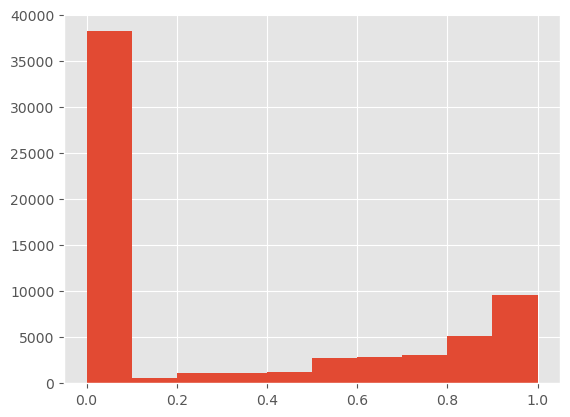

In [232]:
aux_df['response_score'].hist()

Since the view and completion time is now present, we will add two new columns `offer_viewed` and `offer_completed` with binary values.

In [233]:
# Add offer_viewed and offer_completed columns with binary values

aux_df['offer_viewed'] = aux_df['offer_viewed_time'].apply(lambda x: 0 if pd.isnull(x) else 1)
aux_df['offer_completed'] = aux_df['offer_completed_time'].apply(lambda x: 0 if pd.isnull(x) else 1)

In [237]:
aux_df[['offer_viewed_time', 'offer_completed_time', 'offer_viewed', 'offer_completed']].sample(5)

,offer_viewed_time,offer_completed_time,offer_viewed,offer_completed
61045,NaN,NaN,0,0
2963,174.0,264.0,1,1
9553,NaN,NaN,0,0
14299,NaN,NaN,0,0
103600,168.0,198.0,1,1


In [240]:
# Add `redeemed_reward` columns

aux_df['redeemed_reward'] = aux_df.offered_reward * aux_df.offer_completed

To make things clean, three temprary (dummy) dataframes are created. Named `alpha_df`, `beta_df`, and `gamma_df`. In the first two, selection of columns are used and aggregated by sum and mean respectively. In the last, function `split_columns_by_offer_type` is used on a selection of columns to aggregate data by offer type.

In [242]:
# Create dummy dataframes each with different selection of columns and aggregator

alpha_df = aux_df[[
    'customer_id',
    'offer_received',
    'offer_viewed',
    'offer_completed',
    'channel_web',
    'channel_email',
    'channel_mobile',
    'channel_social',
    ]].groupby('customer_id', as_index=True).sum().fillna(0)

beta_df = aux_df[[
    'customer_id',
    'difficulty',
    'duration',
    'offered_reward',
    'redeemed_reward',
    'response_score',
    ]].groupby('customer_id', as_index=True).mean().fillna(0)


### Function: `split_columns_by_offer_type`

This function aggregates specified columns by **offer type** (bogo, discount, informational) for each customer.  

- For each target column, it sums values across offers of the same type:  
  - **Bogo offers:** IDs `[1, 2, 4, 9]`  
  - **Discount offers:** IDs `[5, 6, 7, 10]`  
  - **Informational offers:** IDs `[3, 8]`  
- Returns a DataFrame with `customer_id` as index and new columns for each offer type, e.g., `bogo_offer_viewed_time`, `disc_offer_completed_time`.  

- Values represent the **total aggregated value** of each metric for all offers of that type for a customer.


In [243]:

def split_columns_by_offer_type(df, target_columns):

    # List of offer IDs by type
    bogo_oids = [1, 2, 4, 9]
    disc_oids = [5, 6, 7, 10]
    info_oids = [3, 8]

    # Prepare pivot table
    pivot_cols = ['customer_id', 'offer_id'] + target_columns
    aux_df = pd.pivot_table(
        df[pivot_cols],
        index='customer_id',
        columns='offer_id',
        fill_value=0,
        aggfunc='mean'
    )
    # Flatten multi-level columns
    aux_df.columns = aux_df.columns.map('{0[0]}_oid_{0[1]}'.format)

    # Create output DataFrame
    output_df = pd.DataFrame(index=aux_df.index)

    for column in target_columns:
        # Aggregate values for each offer type
        output_df[f'bogo_{column}'] = sum(aux_df[f'{column}_oid_{i}'] for i in bogo_oids)
        output_df[f'disc_{column}'] = sum(aux_df[f'{column}_oid_{i}'] for i in disc_oids)
        output_df[f'info_{column}'] = sum(aux_df[f'{column}_oid_{i}'] for i in info_oids)

    return output_df


In [244]:
# Target columns to aggregate by offer type
target_columns = [
    'offer_received',
    'offer_viewed',
    'offer_completed',
    'response_score'
]

# split_columns_by_offer_type function
gamma_df = split_columns_by_offer_type(aux_df, target_columns)

,bogo_offer_received,disc_offer_received,info_offer_received,bogo_offer_viewed,disc_offer_viewed,info_offer_viewed,bogo_offer_completed,disc_offer_completed,info_offer_completed,bogo_response_score,disc_response_score,info_response_score
customer_id,,,,,,,,,,,,
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
2,3.0,0.0,1.0,3.0,0.0,1.0,2.0,0.0,1.0,0.64,0.00,0.92
3,1.0,2.0,1.0,1.0,2.0,0.0,1.0,1.0,0.0,0.39,1.00,0.00
4,2.0,2.0,0.0,2.0,2.0,0.0,1.5,2.0,0.0,0.67,1.09,0.00
5,0.0,2.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.00,0.55,0.00


Now, creating the final datframe `coe` which will be used for modeling by megring the above dataframes `alpha_df`, `beta_df`, and `gamma_df` to `profile`.

In [246]:
# Create the final dataset coe

coe = pd.merge(profile.set_index('customer_id'), alpha_df, left_index=True, right_index=True)
coe = pd.merge(coe, beta_df, left_index=True, right_index=True)
coe = pd.merge(coe, gamma_df, left_index=True, right_index=True)

coe.reset_index(inplace=True)

In this step below, sets of new features will be added using function `get_transactions_allotment` that will be helpful in measuring the two main points discussed in _problem statement_. The nomenclature for these features is as follows:

* Prefixes
    * `txn_`: Count of transactions.
    * `amt_`: Sum of amount.
    * `recency_`: Time of most recent transaction.
    * `frequency_`: Average time in hours between transactions.
    * `monetary_`: Average amount per transaction.
* Suffixes
    * `_overall`: Anytime during the test period.
    * `_promo`: During offer durations (regardless of view or completion).
    * `_nonpromo`: In-between (outside) offers durations

The set of `frequency_`, `recency_`, and `monetary_` features is necessary to calculate the RFM score. This [article](https://clevertap.com/blog/rfm-analysis/) was a nice guide in doing so.

### Function: `get_transactions_allotment`

This function computes transaction metrics for each customer, including counts, amounts, and recency for `overall`, `promotional`, and `non-promotional transactions`.

- `Overall transactions`: all transactions of the customer.  
- `Promotional transactions`: transactions occurring during any offer period.  
- `Non-promotional transactions`: transactions outside offer periods.  
- Recency is measured as the `most recent transaction time` in each category.  

Returns a list with the following values:  
`[txn_overall, amt_overall, txn_promo, amt_promo, txn_nonpromo, amt_nonpromo, recency_promo, recency_nonpromo]`  
- Values are `NaN` if no transactions exist in a category.


In [247]:
def get_transactions_allotment(df, aux_df, transactions_df):
    
    # Identify customer
    customer_id = df['customer_id']

    # Get all transactions 'time' and `amount` for identified customer
    # This creates list of lists in the form [time, amount]
    customer_transactions = transactions_df.loc[
        (transactions_df.customer_id == customer_id)
    ][['time', 'amount']].values.tolist()

    # Get `offer_start_time` and `offer_end_time` for all offers received
    # This creates list of lists in the form [offer_start_time, offer_end_time]
    customer_offers = aux_df.loc[
        (aux_df.customer_id == customer_id)
    ][['offer_start_time', 'offer_end_time']].values.tolist()

    # Instantiate list for transactions overall
    overall = []

    # Instantiate list for transactions in promotional periods
    promo = []

    # For each list element in `customer_transactions` list
    for transaction in customer_transactions:
        # Append list element to `overall`
        overall.append(transaction)
        # Get transaction time for logical operation
        txn_time = transaction[0]

        # For each list element in `customer_offers` list
        for offer in customer_offers:
            # Get offer start and end times for logical operation
            offer_start_time = offer[0]
            offer_end_time = offer[1]
            # Assess transaction time during promotional periods and
            # Append list element to `promo`
            if txn_time in range(offer_start_time, offer_end_time + 1):
                promo.append(transaction)


    # PART A - Get overall, promo, nonpromo transactions

    # Convert `overall` and `promo` to set of tuples
    overall = set(tuple(txn) for txn in overall)
    promo = set(tuple(txn) for txn in promo)
    nonpromo = overall - promo

    # Convert back to list to easily access values
    overall = list(overall)
    promo = list(promo)
    nonpromo = list(nonpromo)

    # Output "overall" transactions:
    # Get count of transactions by getting length of `overall`
    txn_overall = len(overall)
    # Get amount of transactions by summing second elements in `overall`
    amt_overall = np.round(
        sum(overall[i][1] for i in range(len(overall))), 2)

    # Output "promo" transactions:
    # Get count of transactions by getting length of `promo`
    txn_promo = len(promo)
    # Get amount of transactions by summing second elements in `promo`
    amt_promo = np.round(
        sum(promo[i][1] for i in range(len(promo))), 2)

    # Output "nonpromo" transactions:
    # Get count of transactions by getting length of `nonpromo`
    txn_nonpromo = len(nonpromo)
    # Get amount of transactions by summing second elements in `nonpromo`
    amt_nonpromo = np.round(
        sum(nonpromo[i][1] for i in range(len(nonpromo))), 2)


    # Part B - Get recency for RFM score

    # Get recency_promo: time of most recent promo transaction
    recency_promo = np.NaN if not promo else promo[-1][0]

    # Get recency_nonpromo: time of most recent nonpromo transaction
    recency_nonpromo = np.NaN if not nonpromo else nonpromo[-1][0]


    # Create return object
    output_value = [txn_overall, amt_overall,
                    txn_promo, amt_promo,
                    txn_nonpromo, amt_nonpromo,
                    recency_promo, recency_nonpromo]

    return output_value


In [248]:

# Apply u.get_transactions_allotment to each row
coe['output_value'] = coe.apply(lambda row: get_transactions_allotment(row, aux_df, transactions_df), axis=1)



In [249]:
# Expand output_value into separate columns
output_cols = [
    'txn_overall', 'amt_overall', 'txn_promo', 'amt_promo',
    'txn_nonpromo', 'amt_nonpromo', 'recency_promo', 'recency_nonpromo'
]

coe[output_cols] = pd.DataFrame(coe['output_value'].tolist(), index=coe.index)

# Drop the temporary output_value column
coe.drop(columns='output_value', inplace=True)

# Compute remaining RFM components
coe['monetary_promo'] = np.round(coe['amt_promo'] / coe['txn_promo'], 2)
coe['monetary_nonpromo'] = np.round(coe['amt_nonpromo'] / coe['txn_nonpromo'], 2)

coe['frequency_promo'] = np.round(coe['recency_promo'] / coe['txn_promo'], 2)
coe['frequency_nonpromo'] = np.round(coe['recency_nonpromo'] / coe['txn_nonpromo'], 2)

Now that the components for the RFM paradigm are prepared, the function `add_rfm_scores` is used to calculate the **RFM scores**.  

- The function uses `pd.qcut` to rank values in each column of:  
  - `frequency_promo`, `recency_promo`, `monetary_promo`  
  - `frequency_nonpromo`, `recency_nonpromo`, `monetary_nonpromo`  
  into **5 bins**.  

- For each customer, the average of the relevant scores is computed to obtain:  
  - `rfm_promo_score`  
  - `rfm_nonpromo_score`  

- The original columns are dropped from the DataFrame.  
- Scores range from **0 to 5**, where 0 indicates no activity and higher values indicate higher customer value.


### Function: `add_rfm_scores`

This function calculates the RFM score for each customer for both promotional and non-promotional transactions.  

- It ranks the values in `recency`, `frequency`, and `monetary` columns into a specified number of bins (default 5) using `pd.qcut`.  
- For each customer, the average of the ranks is computed to obtain:  
  - `rfm_promo_score`  
  - `rfm_nonpromo_score`  
- The original columns used for ranking are dropped from the DataFrame.  
- Scores range from 0 (no activity) to the maximum bin value, indicating higher customer value.


In [253]:
def add_rfm_scores(df, bins=5):
    
    # list of already-existing columns to be ranked
    value_columns = [
        'recency_promo', 'frequency_promo', 'monetary_promo',
        'recency_nonpromo', 'frequency_nonpromo', 'monetary_nonpromo']

    # list of new columns to hold the result of ranking
    rank_columns = [
        'recency_promo_rank', 'frequency_promo_rank', 'monetary_promo_rank',
        'recency_nonpromo_rank', 'frequency_nonpromo_rank', 'monetary_nonpromo_rank']

    # Rank values in `value_columns` and store their rank in `rank_columns`
    for rank, value in zip(rank_columns, value_columns):
        df[rank] = ((pd.qcut(
            df[value], bins, labels=False) + 1).fillna(0)).astype(int)

    # Calculate RFM score for promo
    df['rfm_promo_score'] = np.round(
        ((df[rank_columns[0]] +
        df[rank_columns[1]] +
        df[rank_columns[2]]) / 3), 2)

    # Calculate RFM score for nonpromo
    df['rfm_nonpromo_score'] = np.round(
        ((df[rank_columns[3]] +
        df[rank_columns[4]] +
        df[rank_columns[5]]) / 3) , 2)

    # Drop `value_columns` and `rank_columns`
    df = df.drop(columns=value_columns)
    df = df.drop(columns=rank_columns)

    return df


In [254]:
coe = add_rfm_scores(coe)


In [255]:
coe[['rfm_promo_score', 'rfm_nonpromo_score']].head()

,rfm_promo_score,rfm_nonpromo_score
0,4.67,2.67
1,2.67,4.67
2,4.33,3.33
3,1.67,0.00
4,2.33,0.00


Adding three more features; 
- `amt_per_test_hour`: avergae spent during the test period per hour
- `amt_per_member_day`: avergae spent during the test period per number of membrship days
-  `amt_per_income`: avergae spent during the test period per income.

In [256]:
coe['amt_per_test_hour'] = np.round(coe.amt_overall / transactions_df.time.max(), 6)
coe['amt_per_member_day'] = np.round(coe.amt_overall / coe.days_member, 6)
coe['amt_per_income'] = np.round(coe.amt_overall / coe.income, 6)

In [257]:
coe.drop(columns='customer_id', inplace=True)

In [258]:
coe.shape

(14608, 39)

In [259]:
coe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14608 entries, 0 to 14607
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                14608 non-null  int64  
 1   age                   14608 non-null  int64  
 2   income                14608 non-null  float64
 3   days_member           14608 non-null  int64  
 4   offer_received        14608 non-null  int64  
 5   offer_viewed          14608 non-null  int64  
 6   offer_completed       14608 non-null  int64  
 7   channel_web           14608 non-null  int32  
 8   channel_email         14608 non-null  int32  
 9   channel_mobile        14608 non-null  int32  
 10  channel_social        14608 non-null  int32  
 11  difficulty            14608 non-null  float64
 12  duration              14608 non-null  float64
 13  offered_reward        14608 non-null  float64
 14  redeemed_reward       14608 non-null  float64
 15  response_score     

At this point, dataframe `coe` is ready to be used for modeling to perform user segmentation. It has 39 features and 14608 samples. All features are numerical except `gender` which is a categorical feature represented by binary values.

In [260]:
# Saving the final DataFrame to CSV
coe.to_csv('final_coe.csv', index=False)
